```{raw} jupyter
<div id="qe-notebook-header" align="right" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img style="width:250px;display:inline;" width="250px" src="https://assets.quantecon.org/img/qe-menubar-logo.svg" alt="QuantEcon">
        </a>
</div>
```

# {index}`最优储蓄 IV：时间迭代 <single: 最优储蓄 IV：时间迭代>`

```{contents} Contents
:depth: 2
```

除了 Anaconda 中已有的内容之外，本讲座还需要以下库：

In [1]:
!pip install quantecon

## 概述

在本讲座中，我们将介绍**时间迭代**的核心思想：利用欧拉方程对最优策略的猜测进行迭代。

这种方法与我们在 {doc}`os_stochastic` 中使用的价值函数迭代不同，在那里我们对价值函数本身进行迭代。

时间迭代利用欧拉方程的结构直接求出最优策略，而不是将计算价值函数作为一个中间步骤。

其关键优势在于计算效率：通过直接处理策略函数，我们通常能够比价值函数迭代更快地求解问题。

然而，时间迭代并不是现有基于欧拉方程的方法中最高效的。

在 {doc}`os_egm` 中，我们将介绍**内生网格法**（EGM），它提供了一种更加高效的方式来求解该问题。

目前，我们的目标是理解时间迭代的基本机制以及它如何利用欧拉方程。

让我们从一些导入开始：

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import brentq
from typing import NamedTuple, Callable
import matplotlib as mpl  # i18n
FONTPATH = "fonts/SourceHanSerifSC-SemiBold.otf"  # i18n
mpl.font_manager.fontManager.addfont(FONTPATH)  # i18n
mpl.rcParams['font.family'] = ['Source Han Serif SC']  # i18n

## 欧拉方程

我们的第一步是推导欧拉方程，它是我们在 {doc}`os` 中得到的欧拉方程的推广。

我们采用 {doc}`os_stochastic` 中给出的模型，并添加以下假设：

1. $u$ 和 $f$ 是连续可微且严格凹的
1. $f(0) = 0$
1. $\lim_{c \to 0} u'(c) = \infty$ 且 $\lim_{c \to \infty} u'(c) = 0$
1. $\lim_{k \to 0} f'(k) = \infty$ 且 $\lim_{k \to \infty} f'(k) = 0$

最后两个条件通常称为 **稻田条件（Inada conditions）**。

回顾贝尔曼方程

```{math}
:label: cpi_fpb30

v(x) = \max_{0 \leq c \leq x}
    \left\{
        u(c) + \beta \int v(f(x - c) z) \phi(dz)
    \right\}
\quad \text{for all} \quad
x \in \mathbb R_+
```

设 $v^*$ 为价值函数，设 $\sigma^*$ 为最优消费策略。

我们知道 $\sigma^*$ 是一个 $v^*$-贪婪策略。

上述条件意味着

* $\sigma^*$ 是最优储蓄问题的唯一最优策略
* 最优策略是连续的、严格递增的，并且是**内部的**，即对所有严格为正的 $x$，都有 $0 < \sigma^*(x) < x$，并且
* 价值函数是严格凹的且连续可微的，满足

```{math}
:label: cpi_env

(v^*)'(x) = u' (\sigma^*(x) ) := (u' \circ \sigma^*)(x)
```

由于其与[包络定理](https://en.wikipedia.org/wiki/Envelope_theorem)的关系，最后这个结果被称为**包络条件**。

为了理解 {eq}`cpi_env` 为何成立，将贝尔曼方程写成等价形式

$$
v^*(x) = \max_{0 \leq k \leq x}
    \left\{
        u(x-k) + \beta \int v^*(f(k) z) \phi(dz)
    \right\},
$$

对 $x$ 求导，然后在最优处求值即可得到 {eq}`cpi_env`。

（[EDTC](https://johnstachurski.net/edtc.html) 的第 12.1 节包含了这些结果的完整证明，许多其他文献中也可以找到密切相关的讨论。）

价值函数的可微性和最优策略的内部性意味着最优消费满足与 {eq}`cpi_fpb30` 相关的一阶条件，即

```{math}
:label: cpi_foc

u'(\sigma^*(x)) = \beta \int (v^*)'(f(x - \sigma^*(x)) z) f'(x - \sigma^*(x)) z \phi(dz)
```

将 {eq}`cpi_env` 与一阶条件 {eq}`cpi_foc` 结合起来，得到**欧拉方程**

```{math}
:label: cpi_euler

(u'\circ \sigma^*)(x)
= \beta \int (u'\circ \sigma^*)(f(x - \sigma^*(x)) z) f'(x - \sigma^*(x)) z \phi(dz)
```

我们可以把欧拉方程看作一个函数方程

```{math}
:label: cpi_euler_func

(u'\circ \sigma)(x)
= \beta \int (u'\circ \sigma)(f(x - \sigma(x)) z) f'(x - \sigma(x)) z \phi(dz)
```

它定义在内部消费策略 $\sigma$ 上，其中一个解就是最优策略 $\sigma^*$。

我们的目标是求解函数方程 {eq}`cpi_euler_func`，从而得到 $\sigma^*$。

### Coleman-Reffett 算子

回顾贝尔曼算子

```{math}
:label: fcbell20_coleman

Tv(x) := \max_{0 \leq c \leq x}
\left\{
    u(c) + \beta \int v(f(x - c) z) \phi(dz)
\right\}
```

正如我们引入贝尔曼算子来求解贝尔曼方程一样，我们现在将引入一个作用于策略之上的算子，以帮助我们求解欧拉方程。

这个算子 $K$ 将作用于所有连续、严格递增且内部的 $\sigma \in \Sigma$ 构成的集合。

此后我们用 $\mathscr P$ 表示这个策略集合。

1. 算子 $K$ 以一个 $\sigma \in \mathscr P$ 作为其参数，并且
1. 返回一个新函数 $K\sigma$，其中 $K\sigma(x)$ 是求解下式的 $c \in (0, x)$

```{math}
:label: cpi_coledef

u'(c)
= \beta \int (u' \circ \sigma) (f(x - c) z ) f'(x - c) z \phi(dz)
```

为了纪念 {cite}`Coleman1990` 和 {cite}`Reffett1996` 的工作，我们称这个算子为 **Coleman-Reffett 算子**。

本质上，$K\sigma$ 是当你未来的消费策略为 $\sigma$ 时，欧拉方程告诉你今天应该选择的消费策略。

关于 $K$ 的重要一点是，根据其构造，它的不动点与函数方程 {eq}`cpi_euler_func` 的解相一致。

特别地，最优策略 $\sigma^*$ 是一个不动点。

事实上，对于固定的 $x$，值 $K\sigma^*(x)$ 就是求解下式的 $c$

$$
u'(c)
= \beta \int (u' \circ \sigma^*) (f(x - c) z ) f'(x - c) z \phi(dz)
$$

根据欧拉方程，这恰好是 $\sigma^*(x)$。

### Coleman-Reffett 算子是良定义的吗？

具体来说，是否总是存在唯一的 $c \in (0, x)$ 求解 {eq}`cpi_coledef`？

在我们的假设下，答案是肯定的。

对于任何 $\sigma \in \mathscr P$，{eq}`cpi_coledef` 的右侧

* 在 $(0, x)$ 上关于 $c$ 连续且严格递增
* 当 $c \uparrow x$ 时发散到 $+\infty$

{eq}`cpi_coledef` 的左侧

* 在 $(0, x)$ 上关于 $c$ 连续且严格递减
* 当 $c \downarrow 0$ 时发散到 $+\infty$

绘制这些曲线并利用上述信息，你会相信当 $c$ 在 $(0, x)$ 范围内变化时，它们恰好相交一次。

再进行一些分析，还可以证明：只要 $\sigma \in \mathscr P$，就有 $K \sigma \in \mathscr P$。

### 与 VFI 的比较（理论）

可以证明，$K$ 的迭代与贝尔曼算子的迭代之间存在着紧密的关系。

从数学上讲，$T$ 和 $K$ 在一个变换下是**拓扑共轭**的，该变换在一个方向上涉及微分，在另一个方向上涉及积分。

这种共轭性意味着，如果一个算子的迭代收敛，那么另一个算子的迭代也收敛，反之亦然。

此外，从某种意义上说，它们至少在理论上以*相同的速率*收敛。

然而，事实证明，算子 $K$ 在*数值上*更加稳定，因此在我们考虑的应用中更加高效。

这是因为

* $K$ 利用了额外的结构，因为它使用了一阶条件，并且
* 接近最优策略的策略曲率较小，因此比接近最优价值函数的价值函数更容易近似。

下面给出示例。


## 实现

让我们转向实现。

```{note}
在本讲座中，我们主要关注算法，在代码中优先考虑清晰性而非效率。

在后续讲座中，我们将同时优化算法和代码。
```



与 {doc}`os_stochastic` 中一样，我们假设

* $u(c) = \ln c$
* $f(x-c) = (x-c)^{\alpha}$
* 当 $\zeta$ 为标准正态时，$\phi$ 是 $\xi := \exp(\mu + \nu \zeta)$ 的分布

这使我们能够将结果与我们在那个讲座中得到的解析解进行比较：

In [3]:
def v_star(x, α, β, μ):
    """
    真实价值函数
    """
    c1 = np.log(1 - α * β) / (1 - β)
    c2 = (μ + α * np.log(α * β)) / (1 - α)
    c3 = 1 / (1 - β)
    c4 = 1 / (1 - α * β)
    return c1 + c2 * (c3 - c4) + c4 * np.log(x)

def σ_star(x, α, β):
    """
    真实最优策略
    """
    return (1 - α * β) * x

如上所述，我们的计划是使用时间迭代来求解模型，这意味着用算子 $K$ 进行迭代。

为此，我们需要访问函数 $u'$ 以及 $f, f'$。

我们使用来自 {doc}`os_stochastic` 的相同 `Model` 结构。

In [4]:
class Model(NamedTuple):
    u: Callable        # 效用函数
    f: Callable        # 生产函数
    β: float           # 贴现因子
    μ: float           # 冲击位置参数
    ν: float           # 冲击尺度参数
    grid: np.ndarray   # 状态网格
    shocks: np.ndarray # 冲击抽样
    α: float = 0.4     # 生产函数参数
    u_prime: Callable = None        # 效用的导数
    f_prime: Callable = None        # 生产的导数


def create_model(
        u: Callable,
        f: Callable,
        β: float = 0.96,
        μ: float = 0.0,
        ν: float = 0.1,
        grid_max: float = 4.0,
        grid_size: int = 120,
        shock_size: int = 250,
        seed: int = 1234,
        α: float = 0.4,
        u_prime: Callable = None,
        f_prime: Callable = None
    ) -> Model:
    """
    创建最优储蓄模型的一个实例。
    """
    # 设置网格
    grid = np.linspace(1e-4, grid_max, grid_size)

    # 存储冲击（使用种子，以便结果可复现）
    np.random.seed(seed)
    shocks = np.exp(μ + ν * np.random.randn(shock_size))

    return Model(u, f, β, μ, ν, grid, shocks, α, u_prime, f_prime)

现在我们实现一个名为 `euler_diff` 的方法，它返回

```{math}
:label: euler_diff

u'(c) - \beta \int (u' \circ \sigma) (f(x - c) z ) f'(x - c) z \phi(dz)
```

In [5]:
def euler_diff(c: float, σ: np.ndarray, x: float, model: Model) -> float:
    """
    设置一个函数，使得给定 x 和 σ 时，
    关于 c 的根等于 Kσ(x)。

    """

    # 解包
    u, f, β, μ, ν, grid, shocks, α, u_prime, f_prime = model

    # 通过插值将 σ 转化为一个函数
    σ_func = lambda x: np.interp(x, grid, σ)

    # 现在设置我们需要求根的函数。
    vals = u_prime(σ_func(f(x - c, α) * shocks)) * f_prime(x - c, α) * shocks
    return u_prime(c) - β * np.mean(vals)

函数 `euler_diff` 通过蒙特卡洛计算积分，并使用线性插值来近似函数。

我们将使用求根算法，在给定状态 $x$ 和当前策略猜测 $σ$ 的情况下求解 {eq}`euler_diff` 中的 $c$。

这是算子 $K$，它实现了求根步骤。

In [6]:
def K(σ: np.ndarray, model: Model) -> np.ndarray:
    """
    Coleman-Reffett 算子

    """

    # 解包
    u, f, β, μ, ν, grid, shocks, α, u_prime, f_prime = model

    σ_new = np.empty_like(σ)
    for i, x in enumerate(grid):
        # 求解 x 处的最优 c
        c_star = brentq(euler_diff, 1e-10, x-1e-10, args=(σ, x, model))
        σ_new[i] = c_star

    return σ_new

### 测试

让我们生成一个实例，并从 $σ(x) = x$ 开始绘制 $K$ 的一些迭代结果。

findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


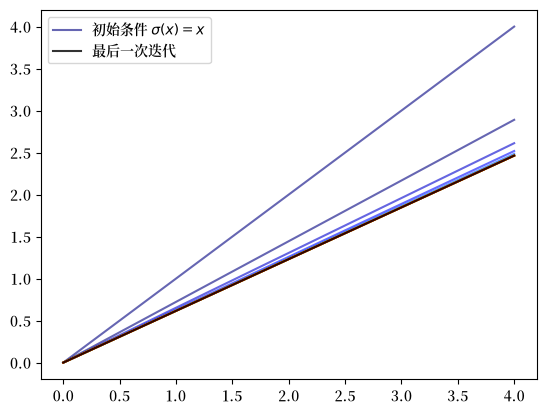

In [7]:
# 定义带导数的效用函数和生产函数
α = 0.4
u = lambda c: np.log(c)
u_prime = lambda c: 1 / c
f = lambda k, α: k**α
f_prime = lambda k, α: α * k**(α - 1)

model = create_model(u=u, f=f, α=α, u_prime=u_prime, f_prime=f_prime)
grid = model.grid

n = 15
σ = grid.copy()  # 设置初始条件

fig, ax = plt.subplots()
lb = r'初始条件 $\sigma(x) = x$'
ax.plot(grid, σ, color=plt.cm.jet(0), alpha=0.6, label=lb)

for i in range(n):
    σ = K(σ, model)
    ax.plot(grid, σ, color=plt.cm.jet(i / n), alpha=0.6)

# 再更新一次，并用黑色绘制最后一次迭代
σ = K(σ, model)
ax.plot(grid, σ, color='k', alpha=0.8, label='最后一次迭代')

ax.legend()

plt.show()

我们看到迭代过程快速收敛到一个极限，该极限与我们在 {doc}`os_stochastic` 中得到的解相似。

这里有一个名为 `solve_model_time_iter` 的函数，它接受一个 `Model` 实例，并使用时间迭代返回最优策略的近似值。

In [8]:
def solve_model_time_iter(
        model: Model,
        σ_init: np.ndarray,
        tol: float = 1e-5,
        max_iter: int = 1000,
        verbose: bool = True
    ) -> np.ndarray:
    """
    使用时间迭代求解模型。

    """
    σ = σ_init
    error = tol + 1
    i = 0

    while error > tol and i < max_iter:
        σ_new = K(σ, model)
        error = np.max(np.abs(σ_new - σ))
        σ = σ_new
        i += 1
        if verbose:
            print(f"Iteration {i}, error = {error}")

    if i == max_iter:
        print("Warning: maximum iterations reached")

    return σ

让我们调用它：

In [9]:
# 解包
grid = model.grid

σ_init = np.copy(grid)
σ = solve_model_time_iter(model, σ_init)

Iteration 1, error = 1.1098265895953756
Iteration 2, error = 0.27827989207957415
Iteration 3, error = 0.09312729948559406
Iteration 4, error = 0.034020038271351805
Iteration 5, error = 0.012820752818722525
Iteration 6, error = 0.004888081560539437
Iteration 7, error = 0.0018718902256100733
Iteration 8, error = 0.0007180512309572507
Iteration 9, error = 0.0002756205293255043
Iteration 10, error = 0.00010582190181418483
Iteration 11, error = 4.063319516900421e-05
Iteration 12, error = 1.5602790842006442e-05
Iteration 13, error = 5.991419175455093e-06


Iteration 13, error = 5.991419175455093e-06


这是所得策略与真实策略的对比图：

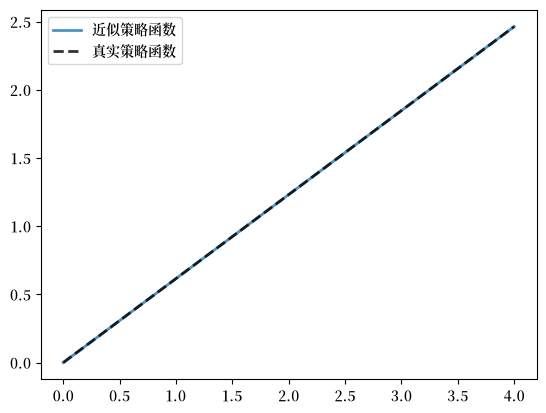

In [10]:
# 解包
grid, α, β = model.grid, model.α, model.β

fig, ax = plt.subplots()

ax.plot(grid, σ, lw=2,
        alpha=0.8, label='近似策略函数')

ax.plot(grid, σ_star(grid, α, β), 'k--',
        lw=2, alpha=0.8, label='真实策略函数')

ax.legend()
plt.show()

同样，拟合效果非常好。

两个策略之间的最大绝对偏差为

In [11]:
# 解包
grid, α, β = model.grid, model.α, model.β

np.max(np.abs(σ - σ_star(grid, α, β)))

np.float64(3.7348959489591493e-06)

正如在 {doc}`os_stochastic` 中所讨论的，时间迭代的运行速度比价值函数迭代更快。

这是因为时间迭代利用了可微性和一阶条件，而价值函数迭代没有使用这一可用的结构。

同时，还有一种运行速度更快的时间迭代变体。

那就是内生网格法，我们将在 {doc}`os_egm` 中介绍它。

## 练习

```{exercise}
:label: cpi_ex1

使用 CRRA 效用求解最优储蓄问题

$$
u(c) = \frac{c^{1 - \gamma}} {1 - \gamma}
$$

设 `γ = 1.5`。

计算并绘制最优策略。
```

```{solution-start} cpi_ex1
:class: dropdown
```

我们定义 CRRA 效用函数及其导数。

In [12]:
γ = 1.5

def u_crra(c):
    return c**(1 - γ) / (1 - γ)

def u_prime_crra(c):
    return c**(-γ)

# 使用与之前相同的生产函数
model_crra = create_model(u=u_crra, f=f, α=α,
                          u_prime=u_prime_crra, f_prime=f_prime)

现在我们求解并绘制策略：

Iteration 1, error = 1.449952719114732
Iteration 2, error = 0.3967698022828947
Iteration 3, error = 0.14845269076775747
Iteration 4, error = 0.06192954031818343
Iteration 5, error = 0.02701766560136787
Iteration 6, error = 0.012019070058329806
Iteration 7, error = 0.005393694573905705
Iteration 8, error = 0.002429984649992001
Iteration 9, error = 0.0010967197524931471
Iteration 10, error = 0.0004953902833375601
Iteration 11, error = 0.0002238472234141753
Iteration 12, error = 0.0001011641350074921
Iteration 13, error = 4.572272482672446e-05
Iteration 14, error = 2.066580711579391e-05
Iteration 15, error = 9.340704450133686e-06
CPU times: user 529 ms, sys: 23.8 ms, total: 553 ms
Wall time: 523 ms


Iteration 4, error = 0.06192954031818343
Iteration 5, error = 0.02701766560136787
Iteration 6, error = 0.012019070058329806
Iteration 7, error = 0.005393694573905705
Iteration 8, error = 0.002429984649992001


Iteration 9, error = 0.0010967197524931471
Iteration 10, error = 0.0004953902833375601
Iteration 11, error = 0.0002238472234141753
Iteration 12, error = 0.0001011641350074921


Iteration 13, error = 4.572272482672446e-05
Iteration 14, error = 2.066580711579391e-05
Iteration 15, error = 9.340704450133686e-06


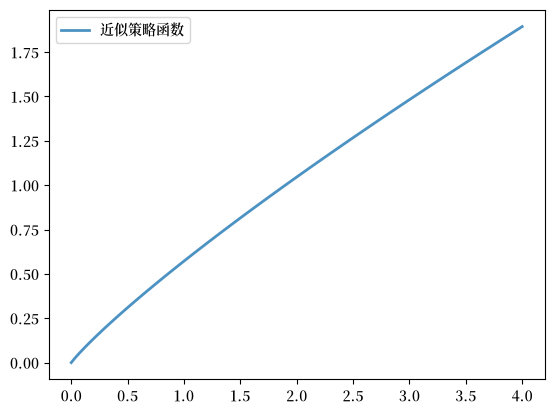

CPU times: user 529 ms, sys: 23.8 ms, total: 553 ms
Wall time: 523 ms


In [13]:
%%time
# 解包
grid = model_crra.grid

σ_init = np.copy(grid)
σ = solve_model_time_iter(model_crra, σ_init)


fig, ax = plt.subplots()

ax.plot(grid, σ, lw=2,
        alpha=0.8, label='近似策略函数')

ax.legend()
plt.show()

```{solution-end}
```